# Avito Bot Detection — решение

## В двух словах

Для каждого cookie нужно оценить вероятность, что это бот. На отложенных датах 17–19 апреля новая модель получила `P@R≥0.70 = 0.8201`, ROC-AUC `0.9459` и average precision `0.8052`. У предыдущей версии значения были 0.7533, 0.9305 и 0.7726.

В модель добавлены признаки темпа действий, пауз, сессий, разнообразия объявлений и движений указателя. Для итогового прогноза усредняются две CatBoost-модели. Ноутбук сохранит результат в `submission.csv`.


## 1. Читаю таблицы

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

from metric import precision_at_recall, pr_curve

RANDOM_STATE = 42
VALIDATION_START = pd.Timestamp("2026-04-17")
DATA_DIR = Path("data")

train = pd.read_csv(
    DATA_DIR / "train.csv",
    parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"],
)
test = pd.read_csv(
    DATA_DIR / "test.csv",
    parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"],
)
events = pd.read_csv(DATA_DIR / "events.csv.gz", parse_dates=["event_ts"])
sample_submission = pd.read_csv(DATA_DIR.parent / "sample_submission.csv")

print(f"train: {train.shape}; test: {test.shape}; events: {events.shape}")
print(f"Доля ботов в train: {train.target.mean():.3%}")
print(f"Период train: {train.window_start_ts.min().date()} — {train.window_start_ts.max().date()}")
print(f"Период test:  {test.window_start_ts.min().date()} — {test.window_start_ts.max().date()}")
train.head()

train: (11091, 5); test: (4909, 4); events: (328905, 14)
Доля ботов в train: 8.106%
Период train: 2026-04-06 — 2026-04-19
Период test:  2026-04-20 — 2026-04-26


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


Перед расчётами проверяю входные таблицы: ID должны быть уникальными, метки — только 0 или 1, а тестовые ID должны совпадать с шаблоном выгрузки. Таблицы ниже показывают пропуски в событиях и самые частые действия.

In [2]:
assert train.cookie_id.is_unique
assert test.cookie_id.is_unique
assert set(train.cookie_id).isdisjoint(set(test.cookie_id))
assert train.target.notna().all() and train.target.isin([0, 1]).all()
assert set(sample_submission.columns) == {"cookie_id", "score"}
assert set(sample_submission.cookie_id) == set(test.cookie_id)

print("Доля пропусков в events:")
display(events.isna().mean().sort_values(ascending=False).to_frame("missing_share"))
print()
print("Типы событий:")
display(events.event_name.value_counts().rename_axis("event_name").to_frame("rows"))

Доля пропусков в events:


,missing_share
search_query,0.694739
search_page,0.694739
pointer_x,0.669996
pointer_y,0.669996
seller_type,0.406966
item_id,0.348420
item_category,0.100090
item_location,0.072340
cookie_id,0.000000
event_ts,0.000000



Типы событий:


,rows
event_name,
item_view,120817
search_results_view,100402
photo_swipe,36517
favorite_add,19049
seller_page_view,17403
contact_phone_show,11316
captcha_shown,7928
login,6267
contact_chat_open,6125


## 2. Смотрю на долю ботов по датам

Это простая проверка обучающей разметки. Если доля ботов заметно меняется во времени, случайное перемешивание дат может дать слишком лёгкую валидацию.

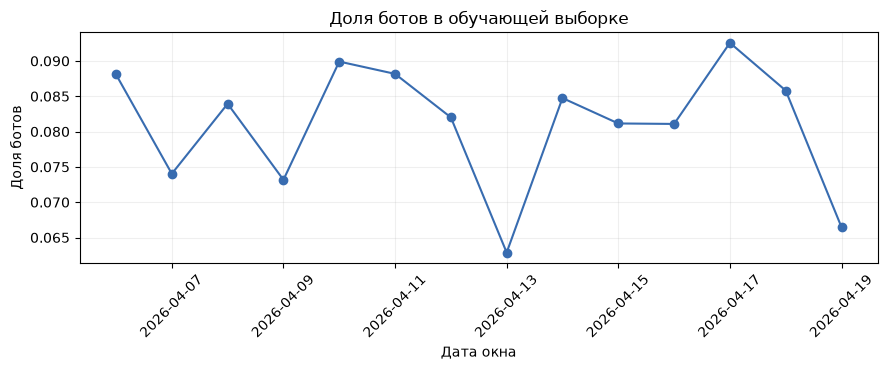

,day,cookies,bot_rate
0,2026-04-06,772,0.088083
1,2026-04-07,797,0.074028
2,2026-04-08,834,0.083933
3,2026-04-09,902,0.073171
4,2026-04-10,912,0.089912
5,2026-04-11,896,0.088170
6,2026-04-12,817,0.082007
7,2026-04-13,843,0.062871
8,2026-04-14,826,0.084746
9,2026-04-15,801,0.081149


In [3]:
daily_rate = (
    train.assign(day=train.window_start_ts.dt.floor("D"))
    .groupby("day", as_index=False)
    .agg(cookies=("target", "size"), bot_rate=("target", "mean"))
)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(daily_rate.day, daily_rate.bot_rate, marker="o", color="#386cb0")
ax.set(title="Доля ботов в обучающей выборке", xlabel="Дата окна", ylabel="Доля ботов")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

display(daily_rate)

Доля ботов по дням здесь меняется примерно от 6% до 9%. Этого достаточно, чтобы дальше проверять модель на более поздних днях, а не полагаться только на случайное разбиение.

## 3. Оставляю события внутри окна наблюдения

В таблице событий есть действия за разные даты. Для каждого cookie нужны только действия между `window_start_ts` и `window_end_ts`: начало включается, конец нет. Сначала добавляю к событиям эти границы, затем убираю всё, что лежит вне окна. Внизу проверяю, что фильтр сработал.

In [4]:
meta_columns = ["cookie_id", "cookie_created_at", "window_start_ts", "window_end_ts"]
meta_all = pd.concat([train[meta_columns], test[meta_columns]], ignore_index=True)

assert meta_all.cookie_id.is_unique
unknown_event_ids = ~events.cookie_id.isin(meta_all.cookie_id)
assert not unknown_event_ids.any(), f"Событий с неизвестными cookie: {unknown_event_ids.sum()}"

bounds = meta_all[["cookie_id", "window_start_ts", "window_end_ts"]]
events_with_windows = events.merge(
    bounds, on="cookie_id", how="left", validate="many_to_one"
)
in_window = (
    events_with_windows.event_ts.ge(events_with_windows.window_start_ts)
    & events_with_windows.event_ts.lt(events_with_windows.window_end_ts)
)
events_windowed = events_with_windows.loc[in_window].copy()
events_windowed = events_windowed.sort_values(
    ["cookie_id", "event_ts"], kind="mergesort"
).reset_index(drop=True)

print(f"Событий всего: {len(events_with_windows):,}")
print(f"Событий в окнах: {len(events_windowed):,}")
assert events_windowed.event_ts.ge(events_windowed.window_start_ts).all()
assert events_windowed.event_ts.lt(events_windowed.window_end_ts).all()

Событий всего: 328,905
Событий в окнах: 288,126


## 4. Собираю признаки для каждого cookie

Модель получает не отдельные события, а сводку по ним: одна строка на cookie. Сначала считаю объём действий, интервалы, доли типов событий и частые значения. Затем добавляю признаки из браузера, ОС, поиска, объявлений и указателя.

Идентификатор cookie не подаётся в модель. Номер объявления тоже не трактуется как число: вместо него считаются число разных объявлений и доля повторов. Энтропия показывает разнообразие: она мала, если почти все действия одного типа, и растёт, когда значения распределены равномернее.

### Небольшие функции для таблиц признаков

Энтропия нужна для категорий: она показывает, равномерно ли cookie распределяет действия по значениям. Мода — самое частое значение. Дальше каждая функция добавляет в общую таблицу одну группу признаков.

In [5]:
def grouped_entropy(frame, key, value_column, output_name):
    """Считает энтропию по заданному столбцу отдельно для каждого cookie."""
    counts = (
        frame.groupby([key, value_column], dropna=False, observed=True)
        .size()
        .rename("count")
        .reset_index()
    )
    counts["share"] = counts["count"] / counts.groupby(key)["count"].transform("sum")
    entropy = (
        counts.assign(term=lambda x: -x.share * np.log(x.share.clip(lower=1e-12)))
        .groupby(key)["term"]
        .sum()
        .rename(output_name)
    )
    return entropy


def grouped_mode(values, cookie_ids):
    """Возвращает самое частое значение для каждого cookie."""
    return values.groupby(cookie_ids, sort=False).agg(
        lambda column: column.value_counts().index[0]
    )

### Сколько событий и какие между ними паузы

Для каждого cookie считаю объём активности, длительность наблюдаемой активности и промежутки между действиями. `diff()` берёт разницу между временем текущего и предыдущего события.

In [6]:
def add_activity_features(events, features):
    """Добавляет число событий, активное время и темп действий."""
    by_cookie = events.groupby("cookie_id", sort=False, observed=True)

    features["n_events"] = by_cookie.size()
    features["n_active_minutes"] = by_cookie.event_ts.apply(
        lambda times: times.dt.floor("min").nunique()
    )

    by_minute = events.assign(event_minute=events.event_ts.dt.floor("min"))
    features["max_events_in_minute"] = (
        by_minute.groupby(["cookie_id", "event_minute"], sort=False)
        .size()
        .groupby("cookie_id")
        .max()
    )

    event_hour = events.event_ts.dt.hour + events.event_ts.dt.minute / 60
    features["first_event_hour"] = event_hour.groupby(events.cookie_id).min()
    features["last_event_hour"] = event_hour.groupby(events.cookie_id).max()
    features["event_hour_std"] = event_hour.groupby(events.cookie_id).std()

    first_event = by_cookie.event_ts.min()
    last_event = by_cookie.event_ts.max()
    features["activity_span_seconds"] = (last_event - first_event).dt.total_seconds()
    features["events_per_active_minute"] = (
        features.n_events / features.n_active_minutes.clip(lower=1)
    )


def add_gap_features(events, features):
    """Добавляет сводку по паузам между соседними событиями."""
    gaps = events.groupby("cookie_id", sort=False).event_ts.diff().dt.total_seconds()
    by_cookie = gaps.groupby(events.cookie_id, sort=False)

    features["gap_mean_seconds"] = by_cookie.mean()
    features["gap_median_seconds"] = by_cookie.median()
    features["gap_std_seconds"] = by_cookie.std()
    features["gap_min_seconds"] = by_cookie.min()
    features["gap_max_seconds"] = by_cookie.max()
    features["gap_cv"] = features.gap_std_seconds / (features.gap_mean_seconds + 1e-3)

    gap_count = gaps.notna().groupby(events.cookie_id, sort=False).sum().replace(0, np.nan)
    for seconds in [1, 2, 5, 10, 30, 60, 300]:
        features[f"gap_share_le_{seconds}s"] = (
            gaps.le(seconds).groupby(events.cookie_id, sort=False).sum() / gap_count
        )
    features["short_gap_count"] = gaps.le(2).groupby(events.cookie_id, sort=False).sum()

### Типы и порядок действий

Считаю число событий каждого типа и долю от всех действий cookie. Затем смотрю на пары соседних действий: например, переход от `search_results_view` к `item_view`. Последняя доля показывает, как часто подряд повторяется один и тот же тип действия.

In [7]:
def add_event_sequence_features(events, features):
    """Добавляет частоты событий и характеристики переходов между ними."""
    event_counts = pd.crosstab(events.cookie_id, events.event_name).add_prefix("event_count__")
    features = features.join(event_counts, how="left")
    for column in event_counts.columns:
        event_name = column.removeprefix("event_count__")
        features[f"event_share__{event_name}"] = features[column] / features.n_events

    events["previous_event"] = events.groupby("cookie_id", sort=False).event_name.shift()
    has_previous = events.previous_event.notna()
    transitions = events.loc[
        has_previous, ["cookie_id", "previous_event", "event_name"]
    ].copy()
    transitions["transition"] = transitions.previous_event + "__to__" + transitions.event_name

    features["n_unique_transitions"] = transitions.groupby("cookie_id").transition.nunique()
    transition_entropy = grouped_entropy(
        transitions, "cookie_id", "transition", "transition_entropy"
    )
    features = features.join(transition_entropy, how="left")

    same_event = events.event_name.eq(events.previous_event) & has_previous
    transition_count = has_previous.groupby(events.cookie_id, sort=False).sum().replace(0, np.nan)
    features["same_event_share"] = (
        same_event.groupby(events.cookie_id, sort=False).sum() / transition_count
    )
    return features

### Информация о браузере и платформе

Из `user_agent` беру только несколько понятных характеристик: семейство браузера, операционную систему, признаки автоматизации и основную версию Chrome. В исходном виде длинную строку браузера модель не использует.

In [8]:
def add_browser_features(events):
    """Приводит платформы к общему виду и разбирает user_agent."""
    events["platform_norm"] = (
        events.platform.fillna("missing").str.lower()
        .replace({"iphone": "ios", "web": "web", "desktop": "web"})
    )
    user_agent = events.user_agent.fillna("").str.lower()

    events["ua_family"] = np.select(
        [
            user_agent.str.contains("headless|phantom", regex=True),
            user_agent.str.contains("yabrowser"),
            user_agent.str.contains("edg/"),
            user_agent.str.contains("firefox"),
            user_agent.str.contains("chrome"),
            user_agent.str.contains("safari"),
        ],
        ["headless_chrome", "yandex", "edge", "firefox", "chrome", "safari"],
        default="other",
    )
    events["ua_os"] = np.select(
        [
            user_agent.str.contains("windows"),
            user_agent.str.contains("macintosh|mac os", regex=True),
            user_agent.str.contains("android"),
            user_agent.str.contains("iphone|ipad|ios", regex=True),
            user_agent.str.contains("linux"),
        ],
        ["windows", "macos", "android", "ios", "linux"],
        default="other",
    )
    events["ua_automation_flag"] = user_agent.str.contains(
        "headless|webdriver|selenium|phantom|puppeteer|playwright", regex=True
    ).astype("int8")
    events["ua_chrome_major"] = pd.to_numeric(
        user_agent.str.extract(r"(?:chrome|headlesschrome)/([0-9]+)", expand=False),
        errors="coerce",
    )

### Разнообразие категорий и тип продавца

Для каждой категории считаю число разных значений, энтропию и наиболее частое значение. Отдельные счётчики дают модели доли действий с каждой платформы, ОС, категорией или типом продавца.

In [9]:
def add_category_features(events, features):
    """Добавляет разнообразие категорий, моды и частоты значений."""
    columns = [
        "platform_norm", "ua_family", "ua_os",
        "item_category", "item_location", "seller_type",
    ]
    for column in columns:
        values = events[column].fillna("missing").astype("string")
        features[f"{column}_nunique"] = values.groupby(events.cookie_id).nunique()

        entropy = grouped_entropy(
            events.assign(_category=values),
            "cookie_id", "_category", f"{column}_entropy",
        )
        features = features.join(entropy, how="left")
        features[f"{column}_mode"] = grouped_mode(values, events.cookie_id)

    count_columns = ["platform_norm", "ua_family", "ua_os", "seller_type", "item_category"]
    for column in count_columns:
        counts = pd.crosstab(events.cookie_id, events[column].fillna("missing"))
        counts = counts.add_prefix(f"{column}__")
        features = features.join(counts, how="left")

    features["ua_automation_share"] = events.groupby("cookie_id").ua_automation_flag.mean()
    features["ua_chrome_major_mean"] = events.groupby("cookie_id").ua_chrome_major.mean()
    features["ua_chrome_major_nunique"] = events.groupby("cookie_id").ua_chrome_major.nunique()
    features["user_agent_nunique"] = events.groupby("cookie_id").user_agent.nunique()
    return features

### Поиск, объявления и указатель

Текст запроса оставляю только как число запросов, число разных запросов и их длину. Для объявлений считаю, сколько раз они повторяются. Координаты указателя свожу к количеству наблюдений, среднему и разбросу; отдельно считаю расстояние между соседними парами координат.

In [10]:
def add_search_and_pointer_features(events, features):
    """Добавляет признаки запросов, объявлений и координат указателя."""
    query = events.search_query.fillna("")
    has_query = query.ne("")
    features["query_event_count"] = has_query.groupby(events.cookie_id).sum()
    features["query_nunique"] = query[has_query].groupby(
        events.loc[has_query, "cookie_id"]
    ).nunique()

    query_length = query[has_query].str.len()
    query_cookie_ids = events.loc[has_query, "cookie_id"]
    features["query_length_mean"] = query_length.groupby(query_cookie_ids).mean()
    features["query_length_max"] = query_length.groupby(query_cookie_ids).max()
    query_words = query[has_query].str.split().str.len()
    features["query_word_count_mean"] = query_words.groupby(query_cookie_ids).mean()

    item_count = events.item_id.groupby(events.cookie_id).count()
    item_nunique = events.item_id.groupby(events.cookie_id).nunique()
    features["item_count"] = item_count
    features["item_nunique"] = item_nunique
    features["item_repeat_share"] = 1 - item_nunique / item_count.replace(0, np.nan)

    for column in ["search_page", "pointer_x", "pointer_y"]:
        values = events[column]
        by_cookie = values.groupby(events.cookie_id)
        features[f"{column}_count"] = by_cookie.count()
        features[f"{column}_nunique"] = by_cookie.nunique()
        features[f"{column}_mean"] = by_cookie.mean()
        features[f"{column}_std"] = by_cookie.std()

    features["pointer_pair_share"] = (
        events.pointer_x.notna() & events.pointer_y.notna()
    ).groupby(events.cookie_id).mean()

    points = events.dropna(subset=["pointer_x", "pointer_y"])
    delta_x = points.groupby("cookie_id", sort=False).pointer_x.diff()
    delta_y = points.groupby("cookie_id", sort=False).pointer_y.diff()
    distance = np.sqrt(delta_x.pow(2) + delta_y.pow(2))
    features["pointer_step_mean"] = distance.groupby(points.cookie_id).mean()
    features["pointer_step_median"] = distance.groupby(points.cookie_id).median()
    features["pointer_zero_step_share"] = distance.eq(0).groupby(points.cookie_id).mean()

### Возраст cookie и сборка таблицы

В конце добавляю то, что известно до классификации: возраст cookie к началу окна, день недели и час создания. Функция вызывает группы выше по очереди и возвращает таблицу в порядке `meta`, то есть одна строка на каждый cookie.

In [11]:
def build_features(events_windowed, meta):
    """Считает базовые признаки; на выходе одна строка для каждого cookie."""
    events = events_windowed.copy()
    meta = meta[meta_columns].copy()
    features = pd.DataFrame(index=pd.Index(meta.cookie_id, name="cookie_id"))

    add_activity_features(events, features)
    add_gap_features(events, features)
    features = add_event_sequence_features(events, features)
    add_browser_features(events)
    features = add_category_features(events, features)
    add_search_and_pointer_features(events, features)

    meta_by_cookie = meta.set_index("cookie_id").reindex(features.index)
    features["cookie_age_hours"] = (
        meta_by_cookie.window_start_ts - meta_by_cookie.cookie_created_at
    ).dt.total_seconds() / 3600
    features["window_weekday"] = meta_by_cookie.window_start_ts.dt.dayofweek
    features["cookie_created_hour"] = meta_by_cookie.cookie_created_at.dt.hour

    features = features.reindex(meta.cookie_id).reset_index()
    categorical = [
        column for column in features.columns
        if pd.api.types.is_object_dtype(features[column])
        or pd.api.types.is_string_dtype(features[column])
    ]
    for column in categorical:
        features[column] = features[column].fillna("missing").astype("string")

    numeric = features.select_dtypes(include=np.number).columns
    features[numeric] = features[numeric].replace([np.inf, -np.inf], np.nan)
    return features

### Строю три набора базовых признаков

Первый нужен для сравнения с прошлой версией. Во втором удалены строки событий, совпадающие по всем исходным столбцам. Третий набор дополнит второй признаками времени, сессий и повторяемости.

In [12]:
X_old_all = build_features(events_windowed, meta_all)

events_clean = events_windowed.drop_duplicates(subset=events.columns).copy()
removed_duplicates = len(events_windowed) - len(events_clean)
print(f"Удалено одинаковых событий: {removed_duplicates:,}")

X_clean_all = build_features(events_clean, meta_all)

Удалено одинаковых событий: 4,293


### Добавляю более подробную статистику

Среднего промежутка между действиями мало: у двух cookie среднее может быть одинаковым, хотя у одного действия идут ровно, а у другого чередуются короткие и длинные паузы. Поэтому дополнительно считаю квантили и разброс пауз, а длинные перерывы использую для приблизительного выделения сессий.

Для просмотров объявлений считаю повторяемость ID, категорий и местоположений. Для указателя — распределение координат и длины перемещений между доступными точками. Пропуск координат остаётся пропуском, а не превращается в нулевое движение.

### Общая сводка по числовым значениям

Одна вспомогательная функция считает одинаковый набор величин для пауз, координат и страниц поиска: среднее, разброс, квантили, асимметрию и максимум.

In [13]:
def add_distribution_stats(row, values, prefix):
    """Записывает сводные числа для одного массива значений."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    row[prefix + "_n"] = len(values)
    if not len(values):
        return

    mean = np.mean(values)
    std = np.std(values)
    row[prefix + "_mean"] = mean
    row[prefix + "_std"] = std
    row[prefix + "_cv"] = std / (abs(mean) + 1e-6)

    labels = ["min", "q10", "q25", "median", "q75", "q90", "max"]
    quantiles = np.quantile(values, [0, .1, .25, .5, .75, .9, 1])
    for label, value in zip(labels, quantiles):
        row[prefix + "_" + label] = value

    if std > 0:
        z = (values - mean) / std
        row[prefix + "_skew"] = np.mean(z**3)
        row[prefix + "_kurtosis"] = np.mean(z**4)


def add_gap_behavior(row, gaps):
    """Сводит все паузы и паузы короче заданных порогов."""
    add_distribution_stats(row, gaps, "gap_all")
    add_distribution_stats(row, np.log1p(gaps), "gap_log")

    for cutoff in [120, 300, 900, 1800]:
        short_gaps = gaps[(gaps > 0) & (gaps < cutoff)]
        add_distribution_stats(row, short_gaps, f"gap_within_{cutoff}")
        if len(short_gaps):
            median = np.median(short_gaps)
            row[f"gap_within_{cutoff}_median_mean"] = median / (short_gaps.mean() + 1e-6)
            row[f"gap_within_{cutoff}_dispersion"] = (
                np.mean(np.abs(short_gaps - median)) / (median + 1e-6)
            )

    row["gap_zero_share"] = np.mean(gaps == 0) if len(gaps) else np.nan
    row["gap_unique_share"] = len(np.unique(gaps)) / max(len(gaps), 1)
    if len(gaps) > 2 and np.std(gaps[:-1]) > 0 and np.std(gaps[1:]) > 0:
        row["gap_lag_correlation"] = np.corrcoef(
            np.log1p(gaps[:-1]), np.log1p(gaps[1:])
        )[0, 1]

### Сессии и часы активности

Пробую три определения сессии: новая начинается после паузы длиннее 5, 15 или 30 минут. Для каждого определения считаю число событий и длительность сессий. Дополнительно разбиваю сутки на отрезки разной длины и проверяю, сосредоточены ли действия в нескольких таких отрезках.

In [14]:
def add_session_features(row, times, gaps, event_count):
    """Считает число, размер и длительность сессий при трёх паузах."""
    for cutoff in [300, 900, 1800]:
        starts = np.r_[0, np.flatnonzero(gaps > cutoff) + 1]
        ends = np.r_[starts[1:] - 1, event_count - 1]
        sizes = ends - starts + 1
        spans = times[ends] - times[starts]

        row[f"session_{cutoff}_count"] = len(starts)
        row[f"session_{cutoff}_size_mean"] = sizes.mean()
        row[f"session_{cutoff}_size_max"] = sizes.max()
        row[f"session_{cutoff}_size_std"] = sizes.std()
        row[f"session_{cutoff}_span_mean"] = spans.mean()
        row[f"session_{cutoff}_span_max"] = spans.max()
        row[f"session_{cutoff}_active_seconds"] = spans.sum()
        row[f"session_{cutoff}_rate"] = event_count / (spans.sum() + len(starts))


def add_clock_features(row, events):
    """Считает долю ночной активности и распределение событий по времени суток."""
    seconds_of_day = (
        events.event_ts.dt.hour * 3600
        + events.event_ts.dt.minute * 60
        + events.event_ts.dt.second
    ).to_numpy()
    row["night_share"] = np.mean(seconds_of_day < 6 * 3600)

    for bin_width in [10, 60, 300, 3600]:
        _, counts = np.unique(seconds_of_day // bin_width, return_counts=True)
        row[f"timebin_{bin_width}_max_share"] = counts.max() / len(events)
        shares = counts / len(events)
        row[f"timebin_{bin_width}_entropy"] = -np.sum(shares * np.log(shares))

### Повторы объявлений, категорий и запросов

Для каждого поля считаю число увиденных значений, долю уникальных, долю самого частого, энтропию и соседние повторы. Затем те же характеристики отдельно считаю для объявлений в поиске и при просмотре карточек.

In [15]:
def add_concentration_features(row, values, prefix):
    """Добавляет меру разнообразия и повторов для одного столбца."""
    observed = values.dropna().to_numpy()
    row[prefix + "_observed"] = len(observed)
    if not len(observed):
        return

    _, counts = np.unique(observed, return_counts=True)
    shares = counts / len(observed)
    entropy = -np.sum(shares * np.log(shares))
    row[prefix + "_unique_ratio"] = len(counts) / len(observed)
    row[prefix + "_top_share"] = shares.max()
    row[prefix + "_hhi"] = np.sum(shares**2)
    row[prefix + "_entropy"] = entropy
    row[prefix + "_entropy_norm"] = entropy / np.log(max(2, len(observed)))
    row[prefix + "_adjacent_repeat"] = (
        np.mean(observed[1:] == observed[:-1]) if len(observed) > 1 else np.nan
    )


def add_content_features(row, events):
    """Считает повторы объявлений, категорий, мест и поисковых запросов."""
    columns = ["item_id", "item_category", "item_location", "search_query", "search_page", "event_name"]
    for column in columns:
        add_concentration_features(row, events[column], "observed_" + column)

    for event_name in ["item_view", "search_results_view"]:
        event_rows = events[events.event_name.eq(event_name)]
        add_concentration_features(row, event_rows.item_id, event_name + "_items")
        add_concentration_features(row, event_rows.item_category, event_name + "_categories")
        add_concentration_features(row, event_rows.item_location, event_name + "_locations")
        if len(event_rows) > 1:
            gaps = event_rows.event_ts.diff().dt.total_seconds().dropna().to_numpy()
            add_distribution_stats(row, gaps[gaps < 900], event_name + "_gap")

### Координаты указателя и страницы поиска

Координаты часто пропущены, поэтому статистики считаются по точкам, где обе координаты есть. Для поиска смотрю на распределение номеров страниц и на то, как часто номер увеличивается.

In [16]:
def add_pointer_features(row, events):
    """Считает распределение координат и расстояния между точками указателя."""
    for column in ["pointer_x", "pointer_y"]:
        values = events[column].dropna().to_numpy()
        add_distribution_stats(row, values, column + "_distribution")
        if len(values):
            row[column + "_zero_share"] = np.mean(values == 0)
            row[column + "_under100_share"] = np.mean(values < 100)
            row[column + "_over1000_share"] = np.mean(values > 1000)
            row[column + "_unique_ratio"] = len(np.unique(values)) / len(values)

    points = events.dropna(subset=["pointer_x", "pointer_y"])
    if len(points) > 1:
        coordinates = points[["pointer_x", "pointer_y"]].to_numpy()
        moves = np.sqrt(np.sum(np.diff(coordinates, axis=0)**2, axis=1))
        add_distribution_stats(row, moves, "pointer_moves")
        row["pointer_moves_zero_share"] = np.mean(moves == 0)
        if coordinates[:, 0].std() > 0 and coordinates[:, 1].std() > 0:
            row["pointer_xy_correlation"] = np.corrcoef(
                coordinates[:, 0], coordinates[:, 1]
            )[0, 1]


def add_search_features(row, events):
    """Считает просмотренные страницы и переходы по поисковой выдаче."""
    search_rows = events[events.search_page.notna()]
    add_distribution_stats(row, search_rows.search_page, "search_page_distribution")
    if len(search_rows):
        pages = search_rows.search_page.to_numpy()
        row["search_deep_share"] = np.mean(pages > 5)
        row["search_very_deep_share"] = np.mean(pages > 10)
        if len(pages) > 1:
            row["search_page_increase_share"] = np.mean(np.diff(pages) > 0)
            row["search_page_step_one_share"] = np.mean(np.diff(pages) == 1)

### Признаки по действиям и клиенту

Считаю, в каких типах событий появляются координаты указателя. В `user_agent` ищу явные названия HTTP-клиентов и приложения Avito.

In [17]:
def add_action_pointer_features(row, events):
    """Считает долю действий с доступными координатами указателя."""
    event_names = [
        "item_view", "search_results_view", "photo_swipe",
        "contact_phone_show", "captcha_shown",
    ]
    for event_name in event_names:
        event_rows = events[events.event_name.eq(event_name)]
        row[event_name + "_pointer_share"] = event_rows.pointer_x.notna().mean()


def add_client_features(row, events):
    """Считает доли явных HTTP-клиентов, приложения и мобильных браузеров."""
    user_agent = events.user_agent.fillna("").str.lower()
    http_client = "python|requests|curl|wget|node-fetch|aiohttp|scrapy|httpx"
    row["ua_http_client_share"] = user_agent.str.contains(http_client, regex=True).mean()
    row["ua_native_app_share"] = user_agent.str.startswith("avito/").mean()
    row["ua_mobile_browser_share"] = user_agent.str.contains("mobile").mean()

### Одна строка дополнительных признаков на cookie

Эта функция только организует вызовы: берёт события одного cookie, вычисляет интервалы и передаёт их небольшим функциям выше. `times` отсчитывается от первого события, а `gaps` — это разницы в секундах между соседними событиями.

In [18]:
def behavior_features(events_windowed, meta):
    """Добавляет расширенные признаки поведения для каждого cookie."""
    rows = []
    for cookie_id, cookie_events in events_windowed.groupby("cookie_id", sort=False):
        event_count = len(cookie_events)
        row = {"cookie_id": cookie_id}

        times = (
            cookie_events.event_ts - cookie_events.event_ts.iloc[0]
        ).dt.total_seconds().to_numpy()
        gaps = np.diff(times)

        add_gap_behavior(row, gaps)
        add_session_features(row, times, gaps, event_count)
        add_clock_features(row, cookie_events)
        add_content_features(row, cookie_events)
        add_pointer_features(row, cookie_events)
        add_search_features(row, cookie_events)
        add_action_pointer_features(row, cookie_events)
        add_client_features(row, cookie_events)
        rows.append(row)

    return (
        pd.DataFrame(rows)
        .set_index("cookie_id")
        .reindex(meta.cookie_id)
        .rename_axis("cookie_id")
        .reset_index()
    )

Соединяю два набора признаков по `cookie_id`. Первый повторяет признаки прежнего решения; второй строится после удаления одинаковых строк событий; третий добавляет статистику поведения. Проверяю, что на каждый cookie приходится одна строка и число столбцов соответствует ожиданиям.

In [19]:
X_extra = behavior_features(events_clean, meta_all)
X_rich_all = X_clean_all.merge(X_extra, on="cookie_id", validate="one_to_one")
feature_sets = {
    "old": X_old_all.drop(columns="cookie_id").copy(),
    "dedup": X_clean_all.drop(columns="cookie_id").copy(),
    "rich": X_rich_all.drop(columns="cookie_id").copy(),
}
for name, frame in feature_sets.items():
    numeric = frame.select_dtypes(include=np.number).columns
    frame[numeric] = frame[numeric].replace([np.inf, -np.inf], np.nan)
    assert len(frame) == len(meta_all)
    print(f"{name}: {frame.shape[1]} признаков")
assert np.array_equal(X_rich_all.cookie_id.to_numpy(), meta_all.cookie_id.to_numpy())
y = train.target.to_numpy()


old: 126 признаков
dedup: 126 признаков
rich: 426 признаков


## 5. Подбираю модель по ранним датам

Сравниваю три варианта признаков и несколько глубин CatBoost. Проверка идёт по времени:

- обучаюсь на днях до 12 апреля, проверяюсь 12–14 апреля;
- обучаюсь на днях до 15 апреля, проверяюсь 15–16 апреля.

Проверяю и среднее вероятностей двух или трёх моделей. Для каждой группы параметров считаю официальную метрику, ROC-AUC и average precision. Выбор делаю по среднему `P@R≥0.70` на двух периодах.

In [20]:
DEVELOPMENT_FOLDS = [("2026-04-12", "2026-04-15"), ("2026-04-15", "2026-04-17")]
MODEL_CONFIGS = {
    "old": ("old", 5, 664),
    "dedup": ("dedup", 5, 664),
    "rich4": ("rich", 4, 900),
    "rich5": ("rich", 5, 900),
    "rich6": ("rich", 6, 900),
}
BLENDS = {"blend456": ["rich4", "rich5", "rich6"],
          "blend45": ["rich4", "rich5"], "blend56": ["rich5", "rich6"]}

def fit_model(name, fit_mask):
    feature_set, depth, iterations = MODEL_CONFIGS[name]
    X = feature_sets[feature_set].iloc[:len(train)]
    categorical = list(X.select_dtypes(include=["object", "string"]).columns)
    model = CatBoostClassifier(
        iterations=iterations, depth=depth, learning_rate=0.04,
        l2_leaf_reg=6, loss_function="Logloss", random_seed=RANDOM_STATE,
        thread_count=4, allow_writing_files=False, verbose=False,
    )
    model.fit(X.loc[fit_mask], y[fit_mask], cat_features=categorical)
    return model

def score_row(name, truth, scores):
    return {"model": name, "P@R≥0.70": precision_at_recall(truth, scores),
            "ROC-AUC": roc_auc_score(truth, scores),
            "Average precision": average_precision_score(truth, scores)}

development_rows = []
for start, end in DEVELOPMENT_FOLDS:
    fit_mask = train.window_start_ts.lt(start).to_numpy()
    valid_mask = (train.window_start_ts.ge(start) & train.window_start_ts.lt(end)).to_numpy()
    predictions = {}
    for name, (feature_set, _, _) in MODEL_CONFIGS.items():
        model = fit_model(name, fit_mask)
        X = feature_sets[feature_set].iloc[:len(train)]
        predictions[name] = model.predict_proba(X.loc[valid_mask])[:, 1]
    for name, members in BLENDS.items():
        predictions[name] = np.mean([predictions[member] for member in members], axis=0)
    for name, scores in predictions.items():
        development_rows.append({"period_start": start, "train_rows": int(fit_mask.sum()),
                                 "validation_rows": int(valid_mask.sum()), "bots": int(y[valid_mask].sum()),
                                 **score_row(name, y[valid_mask], scores)})

development_results = pd.DataFrame(development_rows)
development_summary = development_results.groupby("model")[["P@R≥0.70", "ROC-AUC", "Average precision"]].mean()
development_summary = development_summary.sort_values(["P@R≥0.70", "ROC-AUC"], ascending=False)
selected_name = development_summary.index[0]
selected_members = BLENDS.get(selected_name, [selected_name])
display(development_results[["period_start", "train_rows", "validation_rows", "bots"]].drop_duplicates().reset_index(drop=True))
display(development_results.pivot(index="model", columns="period_start", values="P@R≥0.70").round(4))
display(development_summary.round(4))
print(f"Выбран вариант: {selected_name}; компоненты: {selected_members}")


,period_start,train_rows,validation_rows,bots
0,2026-04-12,5113,2486,190
1,2026-04-15,7599,1541,125


period_start,2026-04-12,2026-04-15
model,,
blend45,0.7112,0.7109
blend456,0.7297,0.7273
blend56,0.7258,0.7458
dedup,0.6837,0.6929
old,0.6520,0.6769
rich4,0.7112,0.7143
rich5,0.6888,0.7213
rich6,0.7337,0.7200


,P@R≥0.70,ROC-AUC,Average precision
model,,,
blend56,0.7358,0.9400,0.7779
blend456,0.7285,0.9403,0.7786
rich6,0.7268,0.9404,0.7792
rich4,0.7128,0.9394,0.7750
blend45,0.7111,0.9400,0.7767
rich5,0.7050,0.9393,0.7749
dedup,0.6883,0.9282,0.7631
old,0.6644,0.9286,0.7630


Выбран вариант: blend56; компоненты: ['rich5', 'rich6']


## 6. Сравниваю с прежней версией на 17–19 апреля

После подбора обучаю выбранные модели на данных до 17 апреля и считаю прогнозы для последних трёх дней. Сравниваю их с прежней моделью и простым Random Forest из quickstart.

`P@R≥0.70` — это наибольшая точность среди порогов, при которых найдено хотя бы 70% ботов. Официальная функция берёт вместе cookie с одинаковым score. Метрика показывает качество ранжирования; рабочий порог для будущего трафика по ней здесь не подбираю.

In [21]:
validation_mask = train.window_start_ts.ge(VALIDATION_START).to_numpy()
y_valid = y[validation_mask]
print(f"Обучение: {(~validation_mask).sum():,}; проверка: {validation_mask.sum():,}; ботов: {y_valid.sum()}")

holdout_models, holdout_predictions = {}, {}
for name in dict.fromkeys(["old"] + selected_members):
    model = fit_model(name, ~validation_mask)
    feature_set = MODEL_CONFIGS[name][0]
    X = feature_sets[feature_set].iloc[:len(train)]
    holdout_models[name] = model
    holdout_predictions[name] = model.predict_proba(X.loc[validation_mask])[:, 1]
old_valid_score = holdout_predictions["old"]
best_valid_score = np.mean([holdout_predictions[name] for name in selected_members], axis=0)

baseline_columns = ["n_events", "item_nunique"]
X_baseline = feature_sets["old"].iloc[:len(train)][baseline_columns]
baseline = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=-1)
baseline.fit(X_baseline.loc[~validation_mask], y[~validation_mask])
baseline_valid_score = baseline.predict_proba(X_baseline.loc[validation_mask])[:, 1]
comparison = pd.DataFrame([
    score_row("Quickstart RandomForest", y_valid, baseline_valid_score),
    score_row("Предыдущая версия", y_valid, old_valid_score),
    score_row("Новая версия: " + selected_name, y_valid, best_valid_score),
]).set_index("model")
display(comparison.round(4))
print(f"Изменение основной метрики: {100 * (precision_at_recall(y_valid, best_valid_score) - precision_at_recall(y_valid, old_valid_score)):+.2f} п.п.")


Обучение: 9,140; проверка: 1,951; ботов: 160


,P@R≥0.70,ROC-AUC,Average precision
model,,,
Quickstart RandomForest,0.1025,0.6074,0.1746
Предыдущая версия,0.7533,0.9305,0.7726
Новая версия: blend56,0.8201,0.9459,0.8052


Изменение основной метрики: +6.68 п.п.


## 7. Смотрю на кривую и важные признаки

Кривая показывает точность при разных значениях полноты. Вертикальная линия отмечает требуемые 70%. Второй график показывает признаки, на которые CatBoost опирался чаще. Высокая важность сама по себе не доказывает, что признак вызывает ботоподобное поведение.

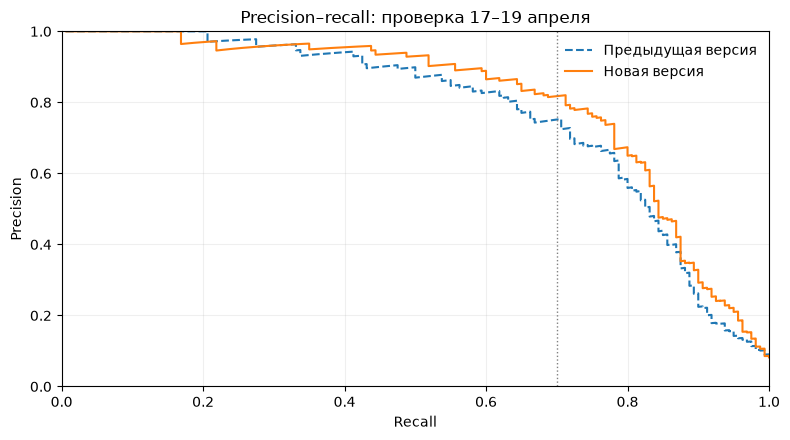

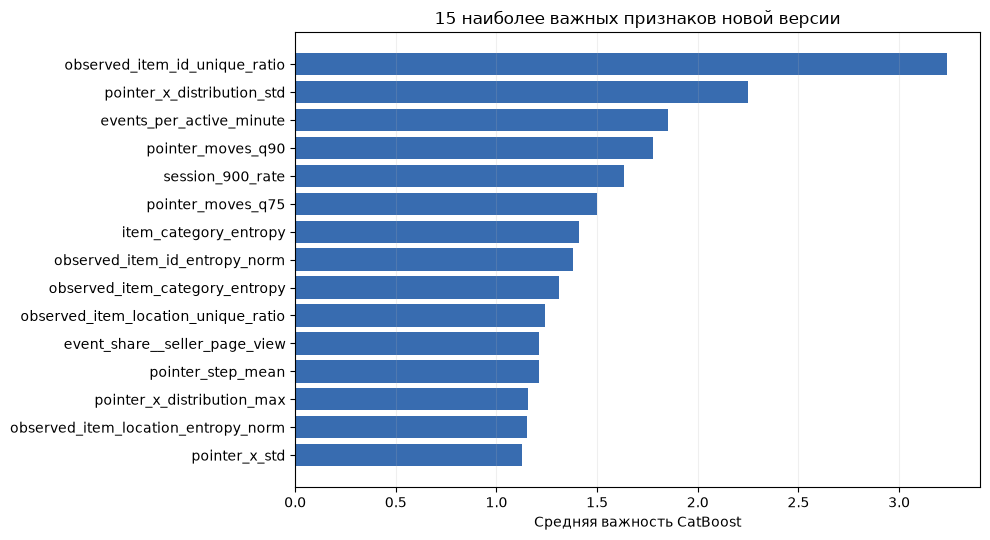

,importance
observed_item_id_unique_ratio,3.240
pointer_x_distribution_std,2.248
events_per_active_minute,1.850
pointer_moves_q90,1.777
session_900_rate,1.635
pointer_moves_q75,1.500
item_category_entropy,1.411
observed_item_id_entropy_norm,1.378
observed_item_category_entropy,1.310
observed_item_location_unique_ratio,1.239


In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for label, scores, style in [("Предыдущая версия", old_valid_score, "--"),
                             ("Новая версия", best_valid_score, "-")]:
    precision_values, recall_values = pr_curve(y_valid, scores)
    ax.plot(recall_values, precision_values, linestyle=style, label=label)
ax.axvline(0.70, color="gray", linestyle=":", linewidth=1)
ax.set(title="Precision–recall: проверка 17–19 апреля", xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1))
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

importance_parts = []
for name in selected_members:
    columns = feature_sets[MODEL_CONFIGS[name][0]].columns
    importance_parts.append(pd.Series(holdout_models[name].get_feature_importance(), index=columns))
importance = pd.concat(importance_parts, axis=1).fillna(0).mean(axis=1).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(importance.index[::-1], importance.to_numpy()[::-1], color="#386cb0")
ax.set(title="15 наиболее важных признаков новой версии", xlabel="Средняя важность CatBoost")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()
display(importance.rename("importance").to_frame().round(3))


На обоих ранних периодах ансамбль глубины 5 и 6 лучше предыдущей версии по основной метрике. На отложенных 17–19 апреля она выросла с 0.7533 до 0.8201. Среди важных признаков оказались число разных объявлений относительно числа просмотров, разброс координат указателя и темп действий.

На этих датах при лучшей точке метрики новая версия нашла 114 из 160 ботов и дала 25 ложных срабатываний; старая нашла 113 ботов и дала 37 ложных срабатываний. Это порог, выбранный по ответам валидации. Для новых данных он заранее неизвестен.

## 8. Обучаю на всех размеченных данных и сохраняю файл

Теперь обучаю выбранные две модели на всех строках `train.csv`. Для каждого тестового cookie усредняю их вероятности. Последний шаг переставляет результат в порядок ID из `sample_submission.csv`, так как порядок строк в тесте и шаблоне может различаться. Итоговый путь — `submission.csv`.

In [23]:
test_predictions = []
for name in selected_members:
    model = fit_model(name, np.ones(len(train), dtype=bool))
    feature_set = MODEL_CONFIGS[name][0]
    X_test = feature_sets[feature_set].iloc[len(train):]
    test_predictions.append(model.predict_proba(X_test)[:, 1])
test_scores = np.mean(test_predictions, axis=0)
predictions_by_cookie = pd.Series(test_scores, index=test.cookie_id, name="score")
submission = sample_submission[["cookie_id"]].copy()
submission["score"] = submission.cookie_id.map(predictions_by_cookie)
assert submission.cookie_id.equals(sample_submission.cookie_id)
assert submission.score.notna().all() and np.isfinite(submission.score).all()
assert submission.score.between(0, 1).all()
assert len(submission) == len(test)
output_path = Path("submission.csv")
submission.to_csv(output_path, index=False)
print(f"Сохранено {len(submission):,} строк: {output_path}")
display(submission.head())


Сохранено 4,909 строк: submission.csv


,cookie_id,score
0,ck_99a4e5ef02d89493,0.013203
1,ck_54d463f7fd89ec3d,0.010384
2,ck_0fbbc7a6af300368,0.001042
3,ck_8fd4937eadd64fb6,0.001547
4,ck_dbb4bd4eda97255d,0.011346
